In [45]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
dengue = pd.read_csv('dengbr22.csv')

C:\Users\Lua.LUADESKTOP\AppData\Local\Temp\ipykernel_2312\3970577942.py:4: DtypeWarning: Columns (44,46,54,101) have mixed types. Specify dtype option on import or set low_memory=False.
  dengue = pd.read_csv('dengbr22.csv')


In [46]:
dengue.columns

Index(['TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'DT_SIN_PRI',
       ...
       'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA', 'TP_SISTEMA',
       'NDUPLIC_N', 'DT_DIGITA', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W'],
      dtype='object', length=121)

<b>Registros por meses</b>: Estudo de contagem de quantas vezes o mês de notificação é registrado, baseado na contagem total de UF. 

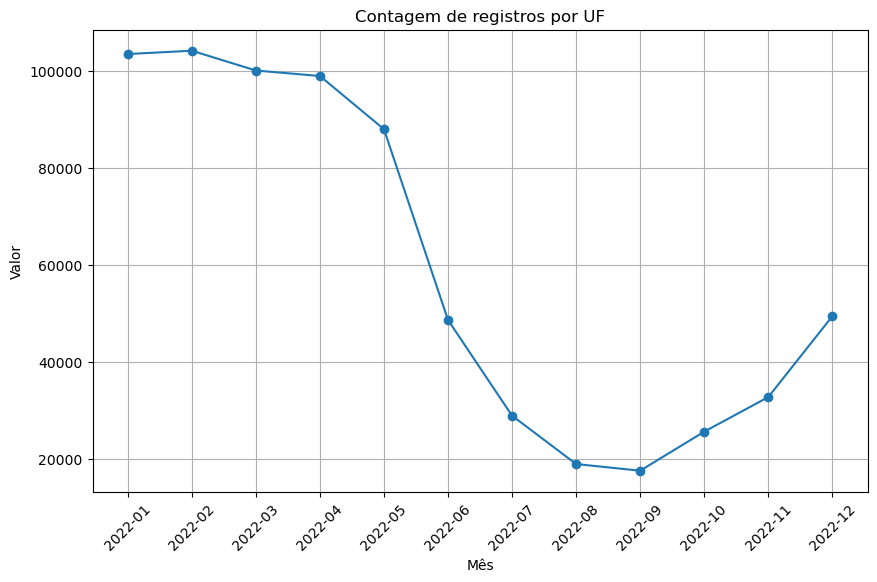

In [47]:
dengue['DT_NOTIFIC'] #Data da notificação
dengue['DT_NOTIFIC'] = pd.to_datetime(dengue['DT_NOTIFIC'])

dengue['dengue_notifi_mes'] = pd.to_datetime(dengue['DT_NOTIFIC']).dt.to_period('M')  #Extrair mês
notifi_por_uf = dengue.groupby('dengue_notifi_mes')['SG_UF_NOT'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(notifi_por_uf['dengue_notifi_mes'].astype(str), notifi_por_uf['SG_UF_NOT'], marker='o', linestyle='-')
plt.title('Contagem de registros por UF')
plt.xlabel('Mês')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [48]:
dengue['SG_UF_NOT'].value_counts()

SG_UF_NOT
17    20846
11    14252
15     5912
13     5356
12     3425
16      290
14       62
Name: count, dtype: int64

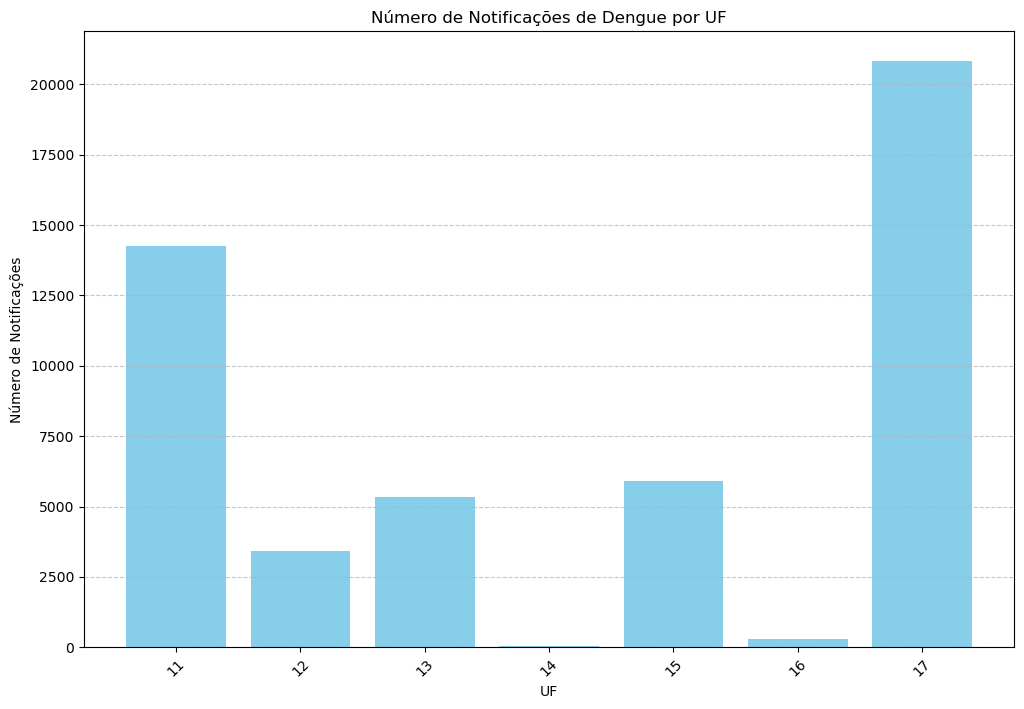

In [49]:
uf_contagem = dengue['SG_UF_NOT'].value_counts().reset_index()
uf_contagem.columns = ['UF', 'Notificacoes']

# Plotar o gráfico de barras
plt.figure(figsize=(12, 8))
plt.bar(uf_contagem['UF'], uf_contagem['Notificacoes'], color='skyblue')
plt.title('Número de Notificações de Dengue por UF')
plt.xlabel('UF')
plt.ylabel('Número de Notificações')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

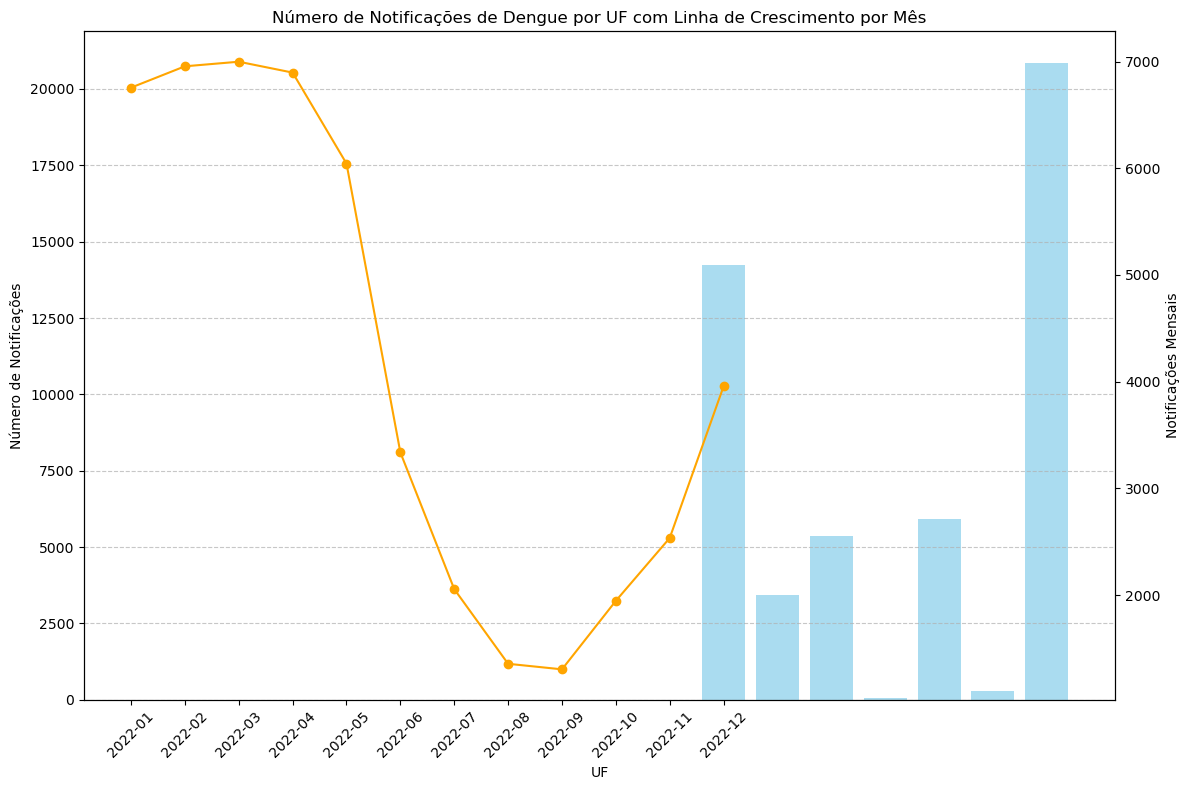

In [50]:
uf_contagem = dengue['SG_UF_NOT'].value_counts().reset_index()
uf_contagem.columns = ['UF', 'Notificacoes']

dengue['dengue_notifi_mes'] = pd.to_datetime(dengue['DT_NOTIFIC']).dt.to_period('M')  #Extrair mês

contagem_mes = dengue.groupby('dengue_notifi_mes').size().reset_index(name='Notificacoes')

# Gráfico de barras para as notificações por UF
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.bar(uf_contagem['UF'], uf_contagem['Notificacoes'], color='skyblue', alpha=0.7)
ax1.set_xlabel('UF')
ax1.set_ylabel('Número de Notificações')
ax1.set_title('Número de Notificações de Dengue por UF com Linha de Crescimento por Mês')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Criar um segundo eixo Y para a linha de crescimento
ax2 = ax1.twinx()
ax2.plot(contagem_mes['dengue_notifi_mes'].astype(str), contagem_mes['Notificacoes'], color='orange', marker='o', linestyle='-')
ax2.set_ylabel('Notificações Mensais')

# Melhorar o layout
fig.tight_layout()
plt.show()

In [51]:
dengue['DT_SIN_PRI'] #Data do primeiro sintoma
dengue['DT_SIN_PRI'] = pd.to_datetime(dengue['DT_SIN_PRI'])

dengue['dengue_sin_mes'] = pd.to_datetime(dengue['DT_SIN_PRI']).dt.to_period('M')  #Extrair mês
dengue['dengue_sin_mes']

sin_por_uf = dengue.groupby('dengue_sin_mes')['SG_UF_NOT'].sum().reset_index()

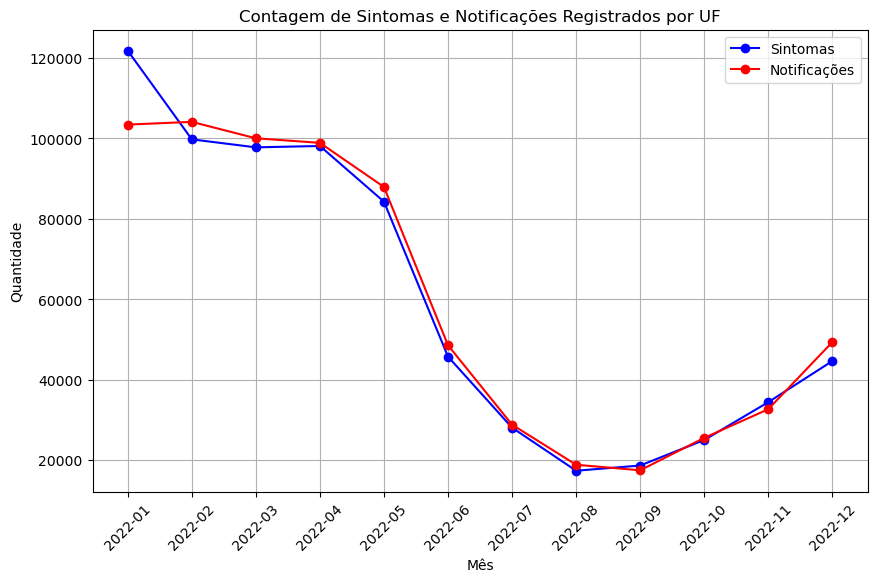

In [52]:
# Criar uma figura e os eixos
plt.figure(figsize=(10, 6))

# Plotar a primeira linha para sintomas registrados por UF
plt.plot(sin_por_uf['dengue_sin_mes'].astype(str), sin_por_uf['SG_UF_NOT'], 
         marker='o', linestyle='-', color='blue', label='Sintomas')

# Plotar a segunda linha para notificações por UF
plt.plot(notifi_por_uf['dengue_notifi_mes'].astype(str), notifi_por_uf['SG_UF_NOT'], 
         marker='o', linestyle='-', color='red', label='Notificações')

# Título e labels dos eixos
plt.title('Contagem de Sintomas e Notificações Registrados por UF')
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45) # Rotacionar os rótulos do eixo X para melhor visualização
plt.grid(True) # Adicionar a grade
plt.legend() # Adicionar a legenda para identificar as linhas
plt.show() # Mostrar o gráfico

In [53]:
# Calcular a diferença entre as dias das datas de notificação e as datas dos sintomas
dengue['diferenca_dias'] = (dengue['DT_NOTIFIC'] - dengue['DT_SIN_PRI']).dt.days

# Ordenar o DataFrame pela coluna 'diferenca_dias' em ordem decrescente
dengue_ordenado = dengue.sort_values(by='diferenca_dias', ascending=False)
resultado_dias = dengue_ordenado[['DT_NOTIFIC', 'DT_SIN_PRI', 'diferenca_dias']]
resultado_dias.head(30)

,DT_NOTIFIC,DT_SIN_PRI,diferenca_dias
19530,2022-12-23,2022-01-16,341.0
24039,2022-12-27,2022-01-27,334.0
4984,2022-12-06,2022-01-29,311.0
19928,2022-11-29,2022-01-26,307.0
14545,2022-12-16,2022-02-12,307.0
19705,2022-11-04,2022-01-02,306.0
19173,2022-12-07,2022-02-05,305.0
14666,2022-12-19,2022-03-05,289.0
29189,2022-12-23,2022-03-20,278.0
27801,2022-12-03,2022-03-02,276.0


In [58]:
resultado_dias.describe() #Conjunto de dados estatísticos

,DT_NOTIFIC,DT_SIN_PRI,diferenca_dias
count,50143,50141,50141.000000
mean,2022-05-17 01:12:01.464611328,2022-05-12 15:45:06.838714624,4.393750
min,2022-01-02 00:00:00,2022-01-02 00:00:00,0.000000
25%,2022-02-23 00:00:00,2022-02-18 00:00:00,2.000000
50%,2022-04-20 00:00:00,2022-04-15 00:00:00,3.000000
75%,2022-07-08 00:00:00,2022-07-04 00:00:00,5.000000
max,2022-12-31 00:00:00,2022-12-31 00:00:00,341.000000
std,NaN,NaN,8.019249


In [ ]:
dengue['DT_INVEST'] #Data de investigação

In [ ]:
dengue['DT_ENCERRA'] #Informar a data do encerramento do caso